In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
df=pd.read_csv(r"D:\ml_udemy\00 ML CODE\Projects\Digital Diagnosis v2\data\raw\dataset.csv")

In [90]:
df.head(5)

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [91]:
df.shape

(246945, 378)

In [92]:
df.isnull().sum()

diseases                            0
anxiety and nervousness             0
depression                          0
shortness of breath                 0
depressive or psychotic symptoms    0
                                   ..
hip weakness                        0
back swelling                       0
ankle stiffness or tightness        0
ankle weakness                      0
neck weakness                       0
Length: 378, dtype: int64

In [93]:
df.columns = [re.sub(r'[^A-Za-z0-9]', '_', col).strip('_').lower() for col in df.columns]

In [94]:
print(df.columns)

Index(['diseases', 'anxiety_and_nervousness', 'depression',
       'shortness_of_breath', 'depressive_or_psychotic_symptoms',
       'sharp_chest_pain', 'dizziness', 'insomnia',
       'abnormal_involuntary_movements', 'chest_tightness',
       ...
       'stuttering_or_stammering', 'problems_with_orgasm', 'nose_deformity',
       'lump_over_jaw', 'sore_in_nose', 'hip_weakness', 'back_swelling',
       'ankle_stiffness_or_tightness', 'ankle_weakness', 'neck_weakness'],
      dtype='object', length=378)


In [95]:
df['diseases'].nunique()

773

diseases
cystitis                          1219
nose disorder                     1218
vulvodynia                        1218
complex regional pain syndrome    1217
spondylosis                       1216
vaginal cyst                      1215
esophagitis                       1215
peripheral nerve disorder         1215
hypoglycemia                      1215
conjunctivitis due to allergy     1215
gastrointestinal hemorrhage       1214
diverticulitis                    1214
acute bronchitis                  1213
infectious gastroenteritis        1212
fungal infection of the hair      1212
sprain or strain                  1212
pneumonia                         1212
spontaneous abortion              1212
gout                              1211
marijuana abuse                   1210
Name: count, dtype: int64


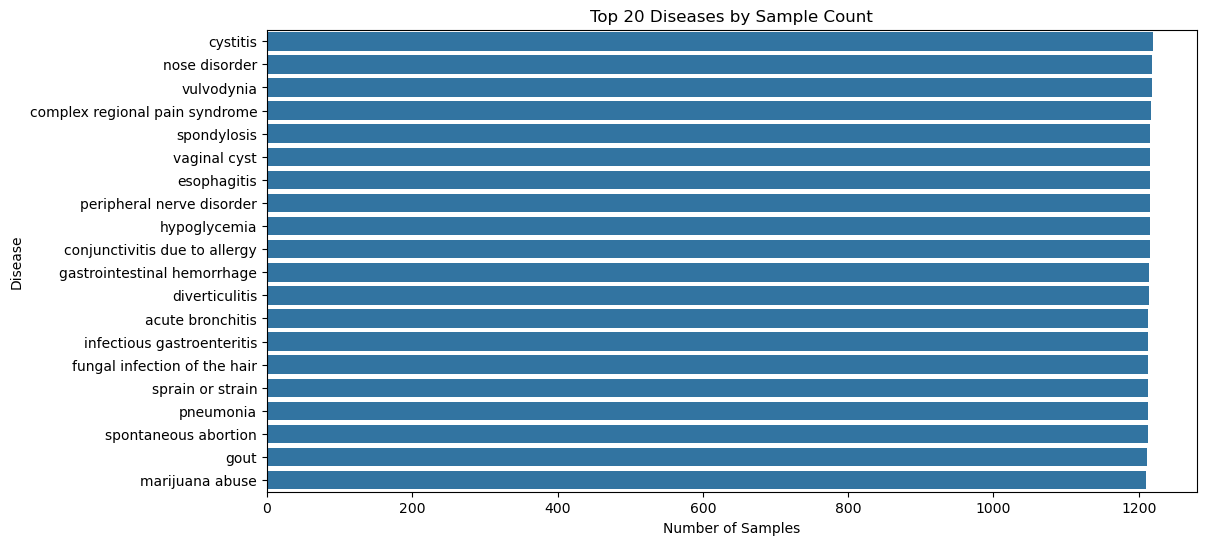

In [96]:
disease_counts = df['diseases'].value_counts()

print(disease_counts.head(20))

plt.figure(figsize=(12,6))
sns.barplot(
    x=disease_counts.head(20).values,
    y=disease_counts.head(20).index
)
plt.title("Top 20 Diseases by Sample Count")
plt.xlabel("Number of Samples")
plt.ylabel("Disease")
plt.show()

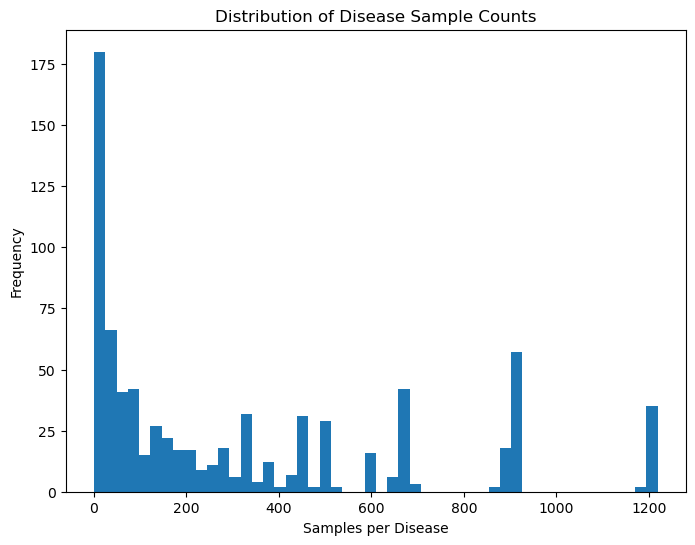

Min samples: 1
Max samples: 1219
Mean samples: 319.46313065976716


In [97]:
plt.figure(figsize=(8,6))
plt.hist(disease_counts.values, bins=50)
plt.title("Distribution of Disease Sample Counts")
plt.xlabel("Samples per Disease")
plt.ylabel("Frequency")
plt.show()

print("Min samples:", disease_counts.min())
print("Max samples:", disease_counts.max())
print("Mean samples:", disease_counts.mean())

In [98]:
df['diseases'].value_counts()

diseases
cystitis                          1219
nose disorder                     1218
vulvodynia                        1218
complex regional pain syndrome    1217
spondylosis                       1216
                                  ... 
open wound of the head               1
myocarditis                          1
chronic ulcer                        1
hypergammaglobulinemia               1
kaposi sarcoma                       1
Name: count, Length: 773, dtype: int64

In [99]:
counts = df['diseases'].value_counts()
rare_diseases = counts[counts >= 200]
print(rare_diseases)


diseases
cystitis                            1219
nose disorder                       1218
vulvodynia                          1218
complex regional pain syndrome      1217
spondylosis                         1216
                                    ... 
acute glaucoma                       210
drug poisoning due to medication     208
benign kidney cyst                   206
pancreatic cancer                    204
trigeminal neuralgia                 201
Name: count, Length: 361, dtype: int64


In [100]:
valid_diseases=disease_counts[disease_counts>=200].index

cleaned_dataset=df[df['diseases'].isin(valid_diseases)]

In [101]:
cleaned_dataset.shape

(224330, 378)

In [102]:
cleaned_dataset['diseases'].nunique()

361

In [103]:
print(cleaned_dataset['diseases'].unique())

['panic disorder' 'atrophic vaginitis' 'eye alignment disorder'
 'vaginitis' 'tinnitus of unknown cause' 'glaucoma' 'eating disorder'
 'transient ischemic attack' 'pyelonephritis' 'chronic pain disorder'
 'problem during pregnancy' 'choledocholithiasis' 'cirrhosis'
 'diabetic retinopathy' 'fibromyalgia' 'ischemia of the bowel'
 'peritonitis' 'acute pancreatitis' 'thrombophlebitis' 'asthma'
 'restless leg syndrome' 'induced abortion' 'teething syndrome'
 'infectious gastroenteritis' 'acute sinusitis'
 'substance-related mental disorder' 'postpartum depression' 'spondylitis'
 'uterine fibroids' 'chalazion' 'vaginal yeast infection'
 'ingrown toe nail' 'corneal disorder' 'viral warts' 'stroke'
 'pilonidal cyst' 'alopecia' 'pelvic organ prolapse' 'fracture of the arm'
 'intracranial hemorrhage' 'hyperkalemia' 'cornea infection'
 'chronic sinusitis' 'conductive hearing loss' 'abdominal hernia'
 'marijuana abuse' 'indigestion' 'bursitis' 'pulmonary congestion'
 'actinic keratosis' 'acute oti

In [104]:
cleaned_dataset.to_csv(r"D:\ml_udemy\00 ML CODE\Projects\Digital Diagnosis v2\data\processed\processed_dataset.csv", index=False)